# Title :Logistic Regression to predict if passenger survived ro not survived classification


In [1]:
import pandas as pd
import matplotlib.pyplot as plt # Import pyplot specifically
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

#  load data set

In [2]:
# load data set titanic
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url)
print(df.head())# Check the first few rows
print ("-----------------")
print(df.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
--

#  EDA Visulization

Survived         0         1
Sex                         
female    0.257962  0.742038
male      0.811092  0.188908


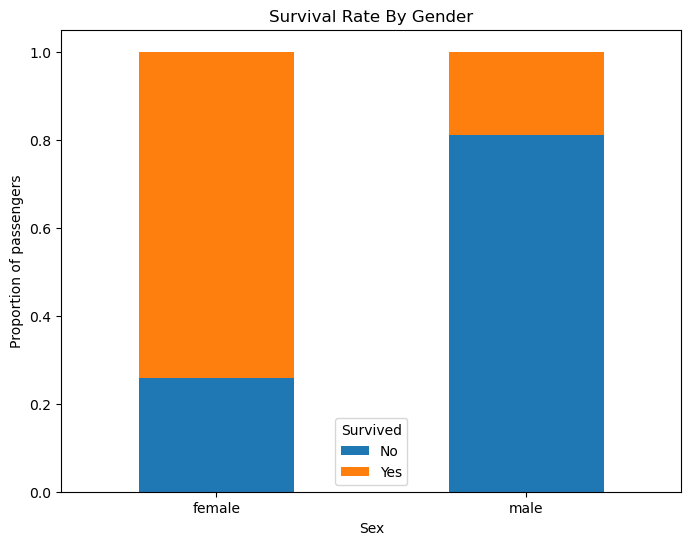

In [3]:
# Did survival depends on gender ? (survived , sex)
survive_sex = df.groupby('Sex')['Survived'].value_counts(normalize=True).unstack()
print(survive_sex)
survive_sex.plot(kind='bar', stacked=True , figsize=(8,6))
plt.title('Survival Rate By Gender')
plt.ylabel('Proportion of passengers')
plt.xticks(rotation=0)
plt.legend(title = 'Survived', labels=['No','Yes'])
plt.show()

Survived         0         1
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363


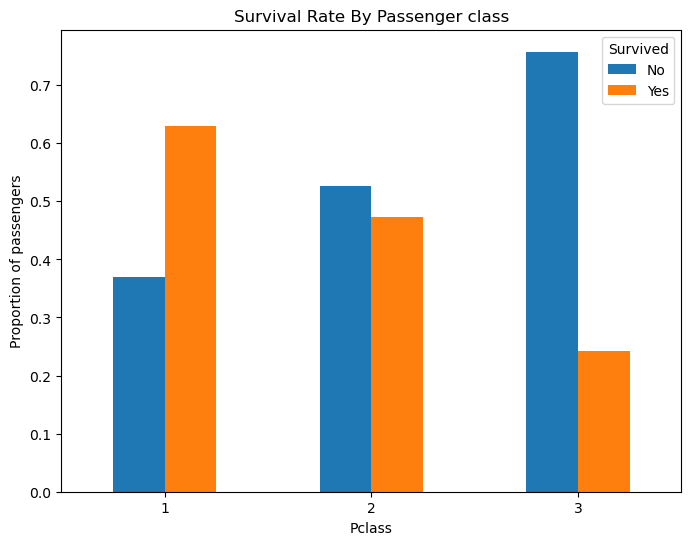

In [4]:
# what about passenger class ? (survived , p class 1 2 3)
survive_pclass = df.groupby('Pclass')['Survived'].value_counts(normalize=True).unstack()
print(survive_pclass)
survive_pclass.plot(kind='bar', figsize=(8,6))
plt.title('Survival Rate By Passenger class')
plt.ylabel('Proportion of passengers')
plt.xticks(rotation=0)
plt.legend(title = 'Survived', labels=['No','Yes'])
plt.show()

# Clean Data


In [5]:
# data cleaning and preprocessing
df_clean=df.copy()
#fill missing age , use median()
median_age= df_clean['Age'].median()
df_clean['Age'].fillna(median_age , inplace = True)
#fill missing embarked with the mode
mode_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'].fillna(mode_embarked  , inplace = True)
#convert catogrical variables into number using one hot encoding
df_clean= pd.get_dummies(df_clean , columns =['Sex','Embarked'], drop_first=True)
#Drop columns that are not useful for modeling
df_clean.drop(['PassengerId' , 'Name' , 'Ticket', 'Cabin'],  axis=1 , inplace = True)
print("---- Clean Data Ready for Modeling")
df_clean.info()

---- Clean Data Ready for Modeling
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


C:\Users\hp\AppData\Local\Temp\ipykernel_10500\2431606759.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(median_age , inplace = True)
C:\Users\hp\AppData\Local\Temp\ipykernel_10500\2431606759.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

# Define features and Target

In [6]:
#Define input feature x and output target y
x_logistic = df_clean.drop('Survived',axis=1)
y_logistic = df_clean['Survived']


# Split Data 

In [7]:
x_train_log , x_test_log ,y_train_log , y_test_log = train_test_split(x_logistic , y_logistic , test_size =0.2 , random_state = 42)

# Scale the feature

In [8]:
scaler_log=StandardScaler()
x_train_log_scaled =scaler_log.fit_transform(x_train_log)
x_test_log_scaled =scaler_log.transform(x_test_log)

# Train the model

In [10]:
log_model= LogisticRegression()
log_model.fit( x_train_log_scaled, y_train_log)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#  Evaluate the logistic model

In [11]:
#make prediction
log_predictions = log_model.predict(x_test_log_scaled)
print("--logistic Regression Model Evaluation--")
print(f"Accuracy score : {accuracy_score (y_test_log ,log_predictions)*100:2f}%")
print("\n Classification Report: ")
print(classification_report(y_test_log ,log_predictions))

--logistic Regression Model Evaluation--
Accuracy score : 81.005587%

 Classification Report: 
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



#  confusion matrix

C:\Users\hp\AppData\Local\Temp\ipykernel_10500\1744886814.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.xaxis.set_ticklabels(['','Not Survive','Survive']);
C:\Users\hp\AppData\Local\Temp\ipykernel_10500\1744886814.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(['','Not Survive','Survive']);


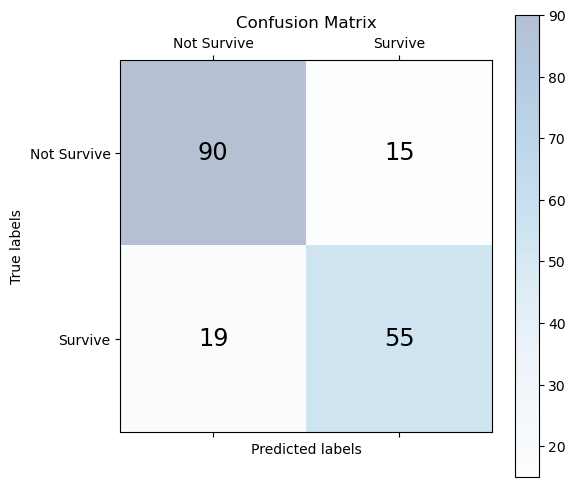

In [14]:
cm = confusion_matrix(y_test_log , log_predictions)
# plot CM
fig,ax = plt.subplots(figsize=(6,6))
cax=ax.matshow(cm, cmap=plt.cm.Blues , alpha=0.3)
fig.colorbar(cax)
for i in range (cm.shape[0]):
  for j in range(cm.shape[1]):
    ax.text(x=j , y =i , s=cm[i,j] , va='center' , ha='center', size='xx-large')
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['','Not Survive','Survive']);
ax.yaxis.set_ticklabels(['','Not Survive','Survive']);
plt.show()